In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
from scipy.integrate import odeint
from scipy.optimize import least_squares, minimize
from ITIS_Model_funcs import get_nominal_param, ITIS, OLS_res
import pickle


In [2]:
paramtitles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']

In [3]:
param_log,IC = get_nominal_param()

##Define time spaces
tstart = 0
t_end =24*8
dt = .05
tspace = np.arange(tstart,t_end,dt)
tfinal = np.arange(0,24+dt,dt)

##Solve the model at nominal values
ode_options = {'rtol': 1e-6}
ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


# t_data = np.linspace(0,24,24+1) # time points every hour
# t_data = np.linspace(0,24,12+1) # less data, every 30 minutes

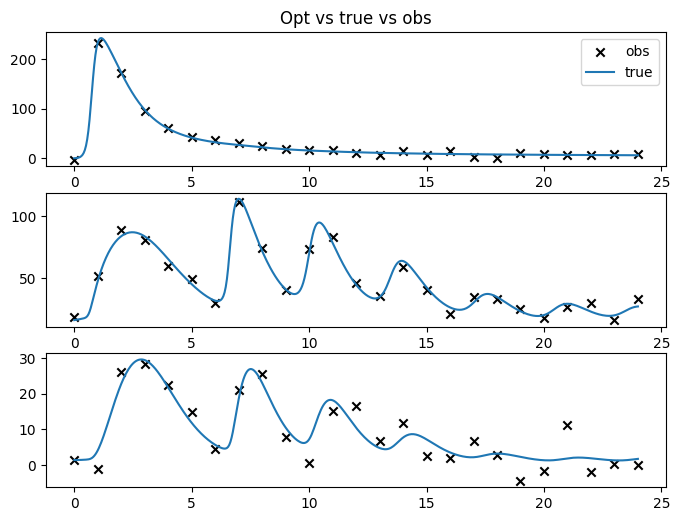

In [4]:
#Generate data

D = '2'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '1'   # '1' for 25, '2' for 13
#
# with open('paramRankings\\rankingDesign' + D + '.pkl', 'rb') as f:
#     results = pickle.load(f)
#
# param_sorted = results['param_sorted']
#
# rank_value = results['rank_value']      # sorted ranking values
# param_sorted_all = results['param_sorted']  #accordingly sorted params as strings
# rank_cut = np.array(rank_value)[np.array(rank_value) > .25 * np.array(rank_value)[0]]
# param_sorted = np.array(param_sorted_all)[:len(rank_cut)]
#
# param_ids = [paramtitles.index(param_sorted[i]) for i in range(len(param_sorted))]


if D == '1':
    output_ids = [6,7]
    param_ids = [33, 12, 36, 32, 43, 39, 16, 7, 31, 37, 8, 15, 9, 28, 14]
elif D == '2':
    output_ids = [3,6,7]
    param_ids = [12, 33, 16, 7, 36, 43, 15, 39, 32, 8, 31, 14, 9, 1, 34]
elif D == '3':
    output_ids = [3,4,6,7]
    param_ids =[12, 33, 7, 36, 16, 43, 15, 39, 32, 8, 9, 31, 21, 14, 10, 34]

##use generated sets instead
with open('syntheticData\\set1_' + D + dpoints + '.pkl', 'rb') as f:
    results = pickle.load(f)
y_data = results['y_data'].copy()
t_data = results['t_data'].copy()


plt.figure(figsize = (8,8))
for i in range(len(output_ids)):
    if i == 1:
        plt.title('Opt vs true vs obs')
        plt.legend()
    plt.subplot(4,1,i+1)
    plt.scatter(t_data,y_data[:,i],marker='x',color='k',label='obs')
    plt.plot(tfinal,true_sol[:,output_ids[i]],label='true')

plt.show()


In [5]:
# MJC - make these bounds based on the parameter values
UB = np.log(np.exp(param_log[param_ids])*10)
LB =  np.log(np.exp(param_log[param_ids])*0.001)


In [6]:
## We will do a global optimization here to see how close we can get to our true data generating
## parameters if we start at multiple locations in parameter space

num_samp  = 20
param_in  = np.zeros((num_samp,len(param_ids)))
param_opt = np.zeros((num_samp,len(param_ids)))
param_all = param_log.copy()
rel_err = np.zeros((num_samp,len(param_ids)))
opt_cost = np.zeros(num_samp) ##why do we only take a vector for this?

var = 0.1
for i in range(num_samp):
#
    param_in [i,:]= np.log(np.exp(param_log[param_ids])*np.random.normal(1,var,(1,len(param_ids))).flatten()) ##MESS WITH BOUNDS
##SAVE PERTURBATION AMOUNT
# Now, we set up a minimization problem
    least_sq_sol = least_squares(OLS_res,param_in[i,:],args=(y_data,t_data,param_ids,output_ids,param_all,IC_2),
                             bounds=(LB,UB),verbose=1,xtol=1e-8,diff_step=1e-4,max_nfev=200)
    param_opt[i,:] = least_sq_sol.x
    rel_err[i,:] = (np.exp(least_sq_sol.x) - np.exp(param_log[param_ids]))/np.exp(param_log[param_ids])
    opt_cost[i] = least_sq_sol.cost
    print(f"sample {i} relative error of solution {rel_err[i,:]}\n")
    print(f"sample {i} cost {opt_cost[i]}\n")
    





`xtol` termination condition is satisfied.
Function evaluations 23, initial cost 1.4591e+01, final cost 2.5920e+00, first-order optimality 2.28e-01.
sample 0 relative error of solution [-0.19289817  0.14394615 -0.17941887  0.6571065  -0.08844544  0.03276629
 -0.38655772  0.06653446  0.03810424 -0.68207839  0.2074863   0.15895633
 -0.12405589 -0.33126881 -0.1017169 ]

sample 0 cost 2.5919763197375927

`xtol` termination condition is satisfied.
Function evaluations 31, initial cost 1.3493e+01, final cost 2.5963e+00, first-order optimality 4.42e-01.
sample 1 relative error of solution [-0.16974     0.1416889  -0.06825044  0.32057304 -0.08855786  0.02725942
 -0.37620142  0.05562727  0.02445656 -0.12852175  0.19317721  0.08319635
  0.4509257  -0.30501067 -0.12561028]

sample 1 cost 2.596341738287099

`xtol` termination condition is satisfied.
Function evaluations 47, initial cost 8.0811e+00, final cost 2.6018e+00, first-order optimality 1.24e-01.
sample 2 relative error of solution [-0.1084

In [7]:
# Now generate the model outputs and plot the parameters
opt_solutions = np.zeros((num_samp,len(tfinal),len(output_ids)))
for i in range(num_samp):
    param_eval = param_log.copy()
    param_eval[param_ids] = param_opt[i,:]

    ##
    opt_model1 = odeint(ITIS, IC, tspace, args = (param_eval,), **ode_options)
    IC_2    = opt_model1[-1,:]
    IC_2[0] = 2.0
    # Resolve model only over 24 hours at subsampled time points. This will be used as our data
    opt_model = odeint(ITIS, IC_2, tfinal, args = (param_eval,), **ode_options)
    for j in range(len(output_ids)):
        opt_solutions[i,:,j] = opt_model[:,output_ids[j]]


ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


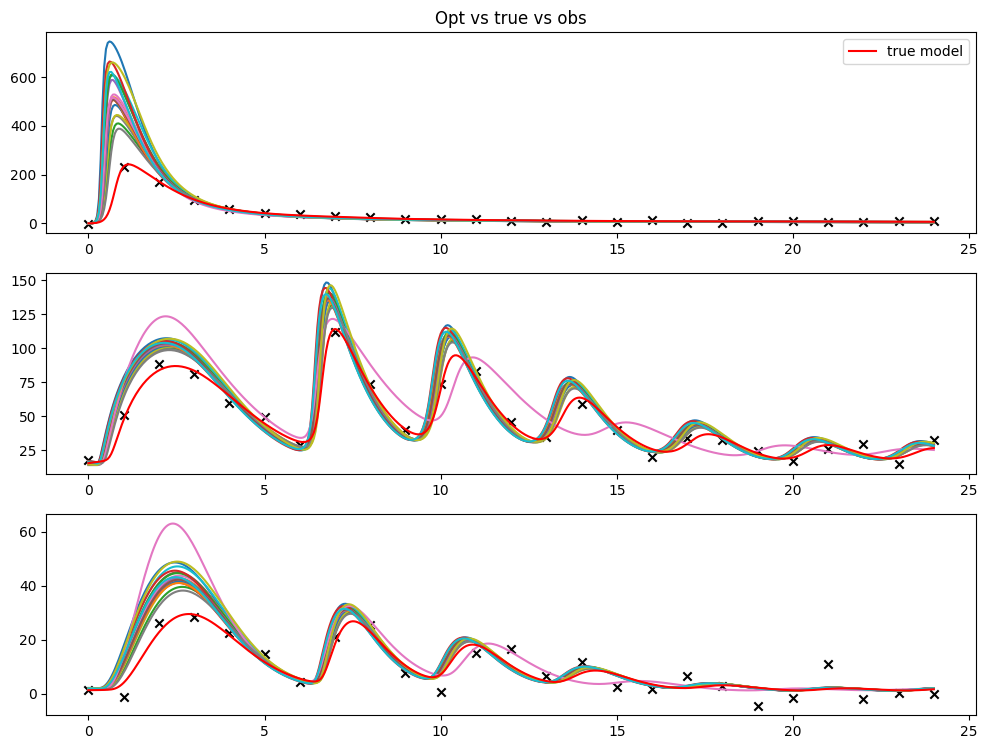

In [8]:

plt.figure(figsize = (12,12))

for i in range(len(output_ids)):
    if i == 1:
        plt.title('Opt vs true vs obs')
        plt.legend()
    plt.subplot(4,1,i+1)
    plt.scatter(t_data,y_data[:,i],marker='x',color='k')
    plt.plot(tfinal,opt_solutions[:,:,i].T)
    plt.plot(tfinal,true_sol[:,output_ids[i]],color='r',label='true model')

#plt.savefig("WLS_FIMSelection\\WLS_32.png")
plt.show()

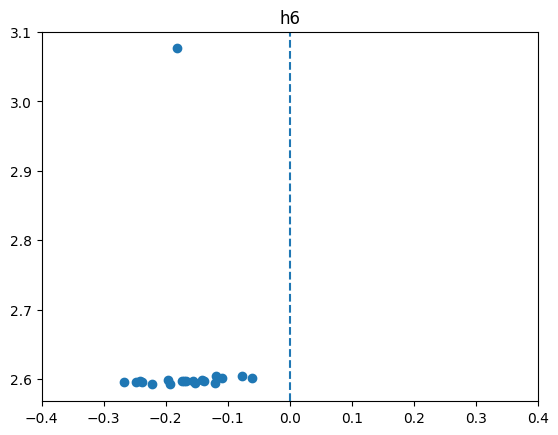

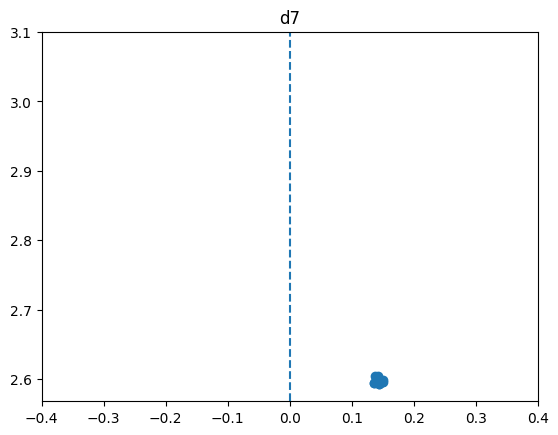

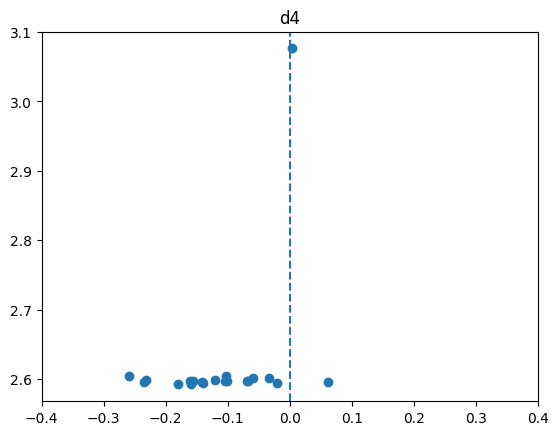

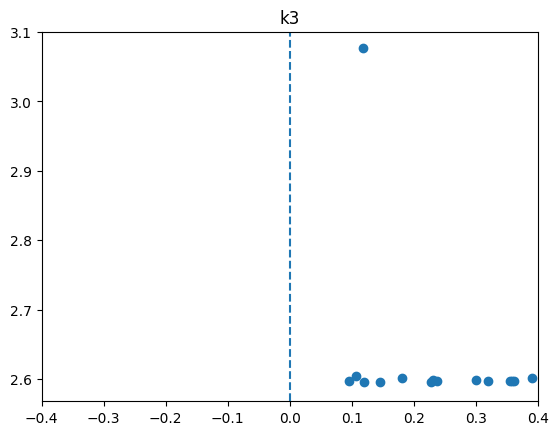

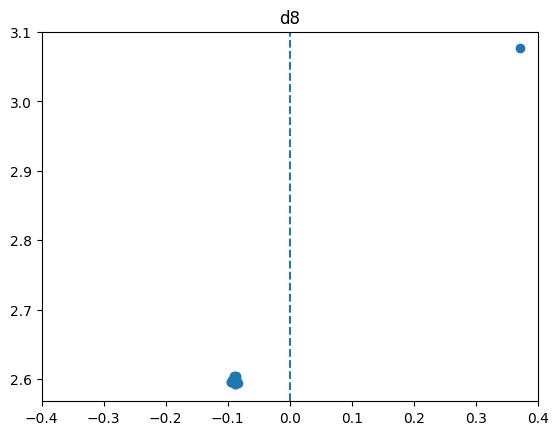

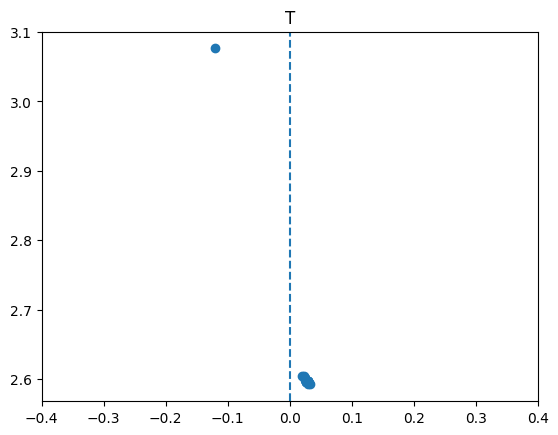

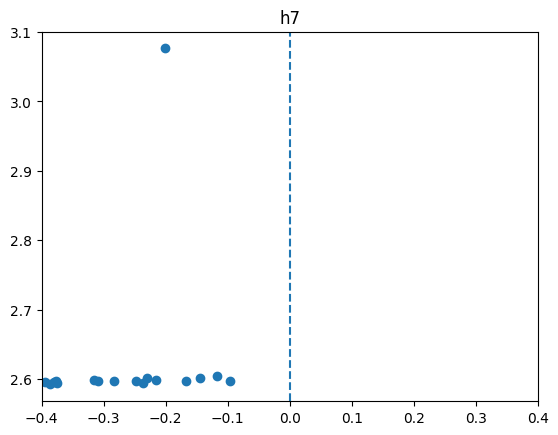

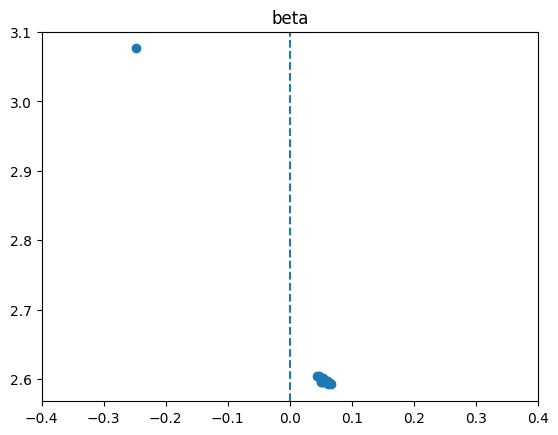

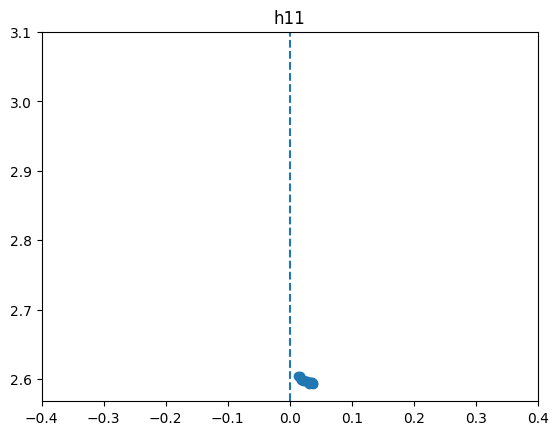

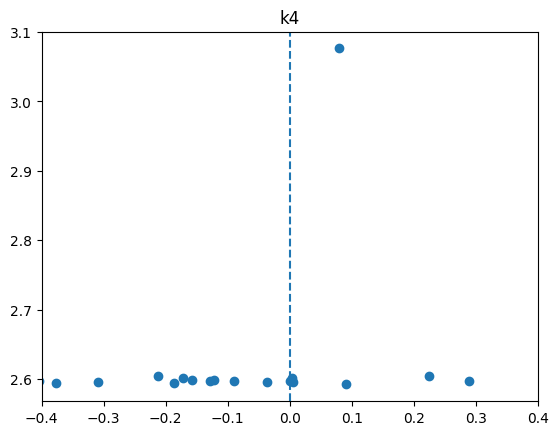

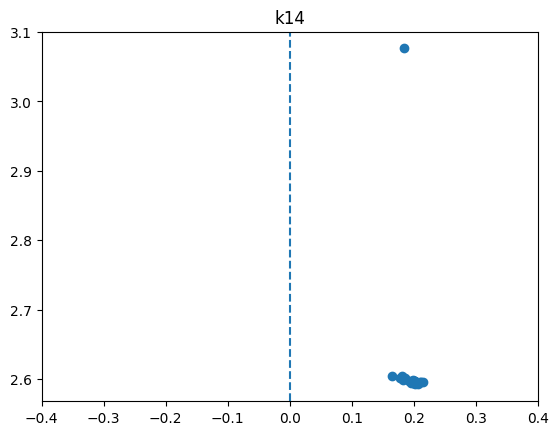

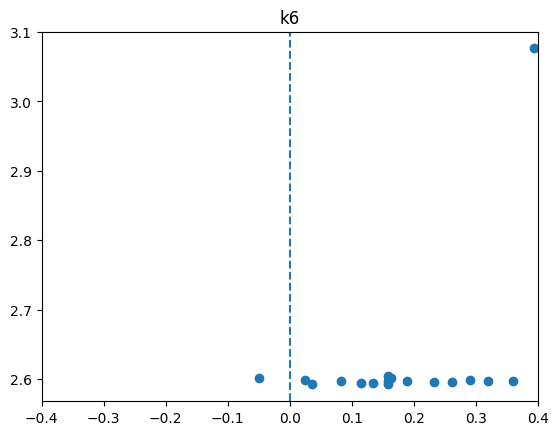

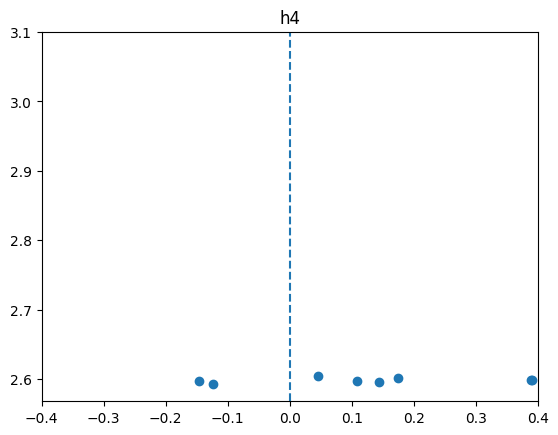

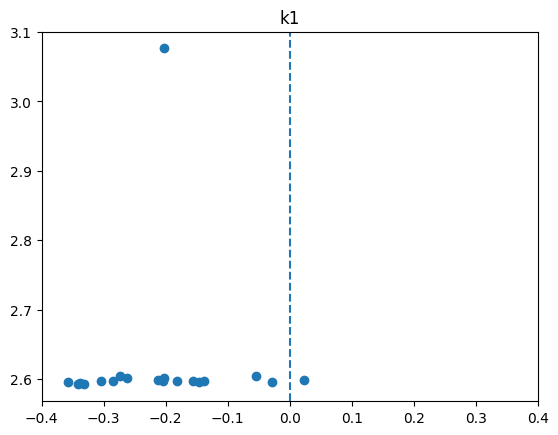

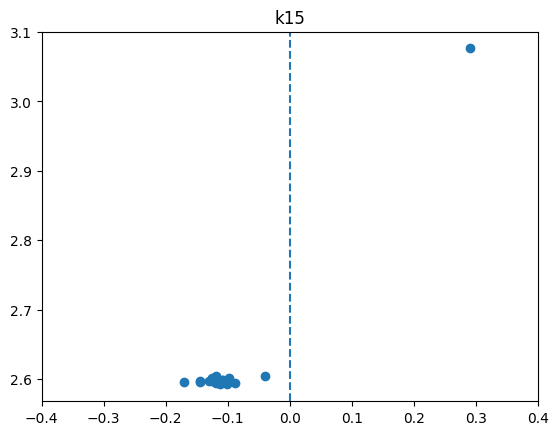

In [9]:
for i in range(len(param_ids)):
    plt.figure()
    # plt.scatter(param_opt[:,i],opt_cost,marker='o')
    # plt.axvline(param_log[param_ids[i]],linestyle='--')

    plt.scatter(rel_err[:,i],opt_cost,marker='o')
    plt.axvline(0,linestyle='--')
    plt.title(paramtitles[param_ids[i]])
    plt.xlim([-0.4,0.4])
    plt.show()


15532.710550314292


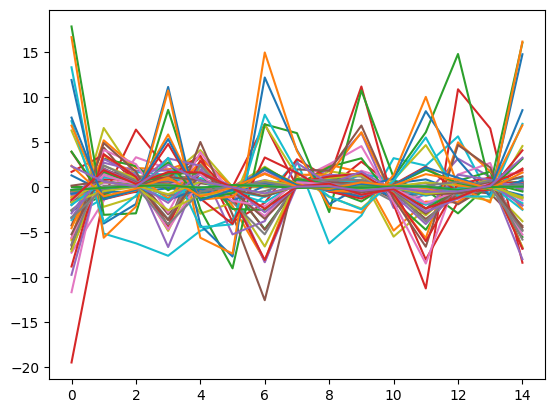

In [10]:
##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_ids) #Just the parameters we optimize
n_states = len(output_ids)
which_opt_param = 2


param_sens_all = param_log.copy()
param_sens_all[param_ids] = param_opt[which_opt_param,:]
Sensitivity_Mat = np.zeros((n_param, len(t_data) * n_states))  ##Initialize shape of sensitivity matrix.
for i in range(n_param):  #calculate the relative sensitivity to each 45 parameters

        param_in = param_sens_all[param_ids[i]]
        param_delta = param_in + h ##    [HOW EXACTLY SHOULD I BE PERTURBING MY PARAM?]
        ##THIS THING NEXT DO THIS!!!
        Sensitivity_Mat[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, param_ids[i], output_ids, param_sens_all, IC)
                                            - OLS_res(param_in, y_data, t_data, param_ids[i], output_ids, param_sens_all, IC)))

twonorms = np.zeros(n_param)

S_opt = Sensitivity_Mat.copy()
F_opt = S_opt@S_opt.T
print(np.linalg.cond(F_opt))

plt.figure()
plt.plot(S_opt)
plt.show()

for i in range(n_param):
        twonorms[i] = np.power(sum(np.power(Sensitivity_Mat[i, :], 2)), 1 / 2)


In [11]:
# #PLOTTING
# paramtitles = ['d1',
#                'k1', 'k2', 'h1', 'h2', 'h3', 'd2',
#                'k3', 'k4', 'h4', 'd3',
#                'h5', 'h6', 'k5', 'k6', 'h7', 'd4',
#                'b1', 'k7', 'h8', 'k8', 'h9', 'd5', 'h10',
#                'b2', 'k9', 'k10', 'k11', 'd6',
#                'k12', 'k13', 'k14', 'h11', 'd7',
#                'k15', 'k16', 'd8',
#                'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']
#
# statetitles = ["Endotoxin", "Phagocytes", "TGF-B", "TNF-a", "IL-10", "CRH", "ACTH", "Cortisol"]
# statetitles_Short = ['endo', 'phag', 'TGFB', 'TNF', 'IL10', 'CRH', 'ACTH', 'cort']
#
# fig, ax = plt.subplots(figsize = (15,5))
# selected_titles = [paramtitles[i] for i in param_ids]
# ax.bar(selected_titles,twonorms)
# plt.xlim(-0.9, len(param_ids) - 1 + 0.9)
#
# ##Plot in descending order
# data = sorted(zip(selected_titles, twonorms), key=lambda v: v[1], reverse = True)
#
# plt.figure(figsize=(15, 5))
# for (i, c) in data:  # unpack and plot each tuple in sorted order
#     bars = plt.bar(i, c, align='center', color = 'cyan')
# plt.xlim(-0.9, len(param_ids) - 1 + 0.9)
#
# #plt.savefig("WLS_FIMSelection\\Sens_WLS_32.png")
# plt.show()

In [12]:
import pickle

all_results = {
    'output_ids': output_ids,
    'param_ids' : param_ids,
    'param_in' : param_in,
    't_data' : t_data,
    'y_data' : y_data,
    'opt_model' : opt_model,
    'true_sol' : true_sol,
    'param_opt' : param_opt,
    'opt_cost' : opt_cost,
    'opt_solutions' : opt_solutions,
    'S_opt' : S_opt,
    'var' : var,
    'rel_err' : rel_err,

}

with open('Multistart_noisydata\\OLSMultistart_noisy' + D + dpoints + '.pkl', 'wb') as f:
    pickle.dump(all_results, f)

